<a href="https://colab.research.google.com/github/bandiamithsreenivasareddy/STRESS-DETECTION-ON-MAUS-USING-DEEP-LEARNING/blob/main/preprocessing_and_cnn_model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install dependencies
!pip install --quiet numpy pandas scipy PyEMD


In [ ]:
# ===========================================
# 0) Install dependencies
# ===========================================


# ===========================================
# 1) Imports
# ===========================================
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
from google.colab import drive

# ===========================================
# 2) Mount Google Drive
# ===========================================
drive.mount('/content/drive')

# ===========================================
# 3) Paths
# ===========================================
DATA_DIR = '/content/drive/MyDrive/MAUS_extracted'
PPG_PATH = os.path.join(DATA_DIR, 'combined_ppg.csv')
GSR_PATH = os.path.join(DATA_DIR, 'combined_gsr.csv')
ECG_PATH = os.path.join(DATA_DIR, 'combined_ecg.csv')

OUT_DIR = os.path.join(DATA_DIR, 'preprocessed')
os.makedirs(OUT_DIR, exist_ok=True)

# ===========================================
# 4) Filtering helper functions
# ===========================================
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return b, a

def apply_bandpass(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data)

def apply_lowpass(data, cutoff, fs, order=4):
    b, a = butter_lowpass(cutoff, fs, order=order)
    return filtfilt(b, a, data)

def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    if max_val - min_val == 0:
        return np.zeros_like(data)
    return (data - min_val) / (max_val - min_val)

# ===========================================
# 5) Processing functions
# ===========================================
def process_ppg(df, fs=256):
    trial_cols = [col for col in df.columns if 'Trial' in col]
    out_df = df.copy()
    for col in trial_cols:
        signal = df[col].dropna().values
        filtered = apply_bandpass(signal, 0.5, 8, fs)
        normalized = min_max_normalize(filtered)
        out_df[col] = normalized
    return out_df

def process_gsr(df, fs=256):
    trial_cols = [col for col in df.columns if 'Trial' in col]
    out_df = df.copy()
    for col in trial_cols:
        signal = df[col].dropna().values
        filtered = apply_lowpass(signal, 1, fs)  # keep slow trends
        normalized = min_max_normalize(filtered)
        out_df[col] = normalized
    return out_df

def process_ecg(df, fs=256):
    trial_cols = [col for col in df.columns if 'Trial' in col]
    out_df = df.copy()
    for col in trial_cols:
        signal = df[col].dropna().values
        filtered = apply_bandpass(signal, 0.5, 40, fs)
        out_df[col] = filtered  # keep amplitude
    return out_df

# ===========================================
# 6) Run preprocessing & save
# ===========================================
print("Processing PPG...")
ppg_df = pd.read_csv(PPG_PATH)
ppg_processed = process_ppg(ppg_df, fs=256)
ppg_processed.to_csv(os.path.join(OUT_DIR, 'preprocessed_ppg.csv'), index=False)

print("Processing GSR...")
gsr_df = pd.read_csv(GSR_PATH)
gsr_processed = process_gsr(gsr_df, fs=256)
gsr_processed.to_csv(os.path.join(OUT_DIR, 'preprocessed_gsr.csv'), index=False)

print("Processing ECG...")
ecg_df = pd.read_csv(ECG_PATH)
ecg_processed = process_ecg(ecg_df, fs=256)
ecg_processed.to_csv(os.path.join(OUT_DIR, 'preprocessed_ecg.csv'), index=False)

print("Preprocessing completed. Files saved to:", OUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing PPG...
Processing GSR...
Processing ECG...
Preprocessing completed. Files saved to: /content/drive/MyDrive/MAUS_extracted/preprocessed


DL MODEL 1

In [ ]:
# ================================
# 0) Install dependencies
# ================================
!pip install tensorflow scikit-learn matplotlib seaborn

# ================================
# 1) Imports
# ================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

# ================================
# 2) Mount Google Drive
# ================================
drive.mount('/content/drive')

# ================================
# 3) Paths to preprocessed files
# ================================
DATA_DIR = '/content/drive/MyDrive/MAUS_extracted/preprocessed'
PPG_FILE = os.path.join(DATA_DIR, 'preprocessed_ppg.csv')
GSR_FILE = os.path.join(DATA_DIR, 'preprocessed_gsr.csv')
ECG_FILE = os.path.join(DATA_DIR, 'preprocessed_ecg.csv')

# ================================
# 4) Data loading
# ================================
ppg_df = pd.read_csv(PPG_FILE)
gsr_df = pd.read_csv(GSR_FILE)
ecg_df = pd.read_csv(ECG_FILE)

print("PPG shape:", ppg_df.shape)
print("GSR shape:", gsr_df.shape)
print("ECG shape:", ecg_df.shape)

# ================================
# 5) Label mapping
# ================================
def map_label(col_name):
    name_lower = col_name.lower()
    if "0back" in name_lower:
        return 0  # low stress
    elif "2back" in name_lower or "3back" in name_lower:
        return 1  # high stress
    else:
        return None

trial_cols = [c for c in ppg_df.columns if "trial" in c.lower()]
labels = []
for col in trial_cols:
    labels.append(map_label(col))

valid_idx = [i for i, lbl in enumerate(labels) if lbl is not None]
trial_cols = [trial_cols[i] for i in valid_idx]
labels = np.array([labels[i] for i in valid_idx])

# ================================
# 6) Prepare data (samples × timesteps × channels)
# ================================
X_ppg = ppg_df[trial_cols].T.values
X_gsr = gsr_df[trial_cols].T.values
X_ecg = ecg_df[trial_cols].T.values

# Stack channels
X = np.stack([X_ppg, X_gsr, X_ecg], axis=-1)  # shape: (samples, timesteps, channels)
y = labels

print("Data shape before slicing:", X.shape)  # e.g. (6, 1689600, 3)

# ================================
# 7) Slice the long sequences into smaller windows
# ================================
window_size = 5000

def slice_signal(signal, window_size):
    slices = []
    total_length = signal.shape[0]
    num_slices = total_length // window_size  # integer division, ignore leftover
    for i in range(num_slices):
        start = i * window_size
        slices.append(signal[start:start + window_size])
    return np.array(slices)

X_slices = []
y_slices = []

for i in range(X.shape[0]):
    slices = slice_signal(X[i], window_size)
    X_slices.append(slices)
    y_slices.extend([y[i]] * slices.shape[0])

X_slices = np.vstack(X_slices)
y_slices = np.array(y_slices)

print("Data shape after slicing:", X_slices.shape)  # (total_slices, window_size, channels)
print("Labels shape after slicing:", y_slices.shape)


# ================================
# 8) Data augmentation: Gaussian jitter
# ================================
def gaussian_jitter(data, sigma=0.01):
    noise = np.random.normal(0, sigma * np.std(data, axis=1, keepdims=True), data.shape)
    return data + noise

X_aug = gaussian_jitter(X_slices)
y_aug = y_slices.copy()

# Concatenate original + augmented data
X_all = np.concatenate([X_slices, X_aug], axis=0)
y_all = np.concatenate([y_slices, y_aug], axis=0)

print("Data shape after augmentation:", X_all.shape)

# ================================
# 9) Train/Val/Test split
# ================================
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ================================
# 10) Model definition
# ================================
model = Sequential([
    Conv1D(128, kernel_size=3, activation='relu', input_shape=(window_size, X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(512, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ================================
# 11) Callbacks
# ================================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# ================================
# 12) Training
# ================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ================================
# 13) Evaluation on test set
# ================================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Stress', 'High Stress']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ================================
# 14) Loss & accuracy plots
# ================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

# ================================
# 15) GFLOPS & params (optional)
# ================================
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
print("Trainable params:", trainable_params)
print("Non-trainable params:", non_trainable_params)

# ================================
# 16) Save model and weights
# ================================
SAVE_DIR = '/content/drive/MyDrive/MAUS_extracted/models'
os.makedirs(SAVE_DIR, exist_ok=True)
model.save(os.path.join(SAVE_DIR, 'stress_cnn_model.h5'))
model.save_weights(os.path.join(SAVE_DIR, 'stress_cnn_weights.h5'))

print("Model and weights saved to:", SAVE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PPG shape: (1689600, 8)
GSR shape: (1689600, 8)
ECG shape: (1689600, 8)
Data shape before slicing: (6, 1689600, 3)
Data shape after slicing: (2022, 5000, 3)
Labels shape after slicing: (2022,)
Data shape after augmentation: (4044, 5000, 3)
Train shape: (2426, 5000, 3)
Validation shape: (809, 5000, 3)
Test shape: (809, 5000, 3)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 589s 8s/step - accuracy: 0.6750 - loss: 21.6113 - val_accuracy: 0.3337 - val_loss: 11.1728
Epoch 2/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 621s 8s/step - accuracy: 0.7561 - loss: 3.4422 - val_accuracy: 0.8146 - val_loss: 2.1954
Epoch 3/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 618s 8s/step - accuracy: 0.8014 - loss: 1.4603 - val_accuracy: 0.7120 - val_loss: 2.1377
Epoch 4/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 583s 8s/step - accuracy: 0.8413 - loss: 0.7142 - val_accuracy: 0.4400 - val_loss: 8.5175
Epoch 5/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 621s 8s/step - accuracy: 0.8281 - loss: 0.7374 - val_accuracy: 0.4326 - val_loss: 16.9989
Epoch 6/200
15/76 ━━━━━━━━━━━━━━━━━━━━ 7:09 7s/step - accuracy: 0.8231 - loss: 0.8825

KeyboardInterrupt: 

In [ ]:
# Print all columns in ppg_df
print("All columns in ppg_df:")
for col in ppg_df.columns:
    print(col)

# Print columns that contain 'trial' (case-insensitive)
trial_cols = [c for c in ppg_df.columns if "trial" in c.lower()]
print("\nColumns containing 'trial':")
for col in trial_cols:
    print(col)


All columns in ppg_df:
Trial 1:0back
Trial 2:2back
Trial 3:3back
Trial 4:2back
Trial 5:3back
Trial 6:0back
subject
file

Columns containing 'trial':
Trial 1:0back
Trial 2:2back
Trial 3:3back
Trial 4:2back
Trial 5:3back
Trial 6:0back


Mounted at /content/drive
PPG shape: (1689600, 8)
GSR shape: (1689600, 8)
ECG shape: (1689600, 8)
Data shape before slicing: (6, 1689600, 3)
Data shape after slicing: (2022, 5000, 3)
Labels shape after slicing: (2022,)
Data shape after augmentation: (4044, 5000, 3)
Train shape: (2426, 5000, 3)
Validation shape: (809, 5000, 3)
Test shape: (809, 5000, 3)
Epoch 1/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 40s 485ms/step - accuracy: 0.6994 - loss: 1.9832 - val_accuracy: 0.3572 - val_loss: 1.0196
Epoch 2/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 448ms/step - accuracy: 0.8793 - loss: 0.7385 - val_accuracy: 0.3399 - val_loss: 2.3473
Epoch 3/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 40s 434ms/step - accuracy: 0.9384 - loss: 0.2755 - val_accuracy: 0.5340 - val_loss: 0.8729
Epoch 4/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 431ms/step - accuracy: 0.9690 - loss: 0.1188 - val_accuracy: 0.5031 - val_loss: 1.4417
Epoch 5/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 34s 444ms/step - accuracy: 0.9811 - loss: 0.0645 - val_accuracy: 0.6230 - val_loss: 1.

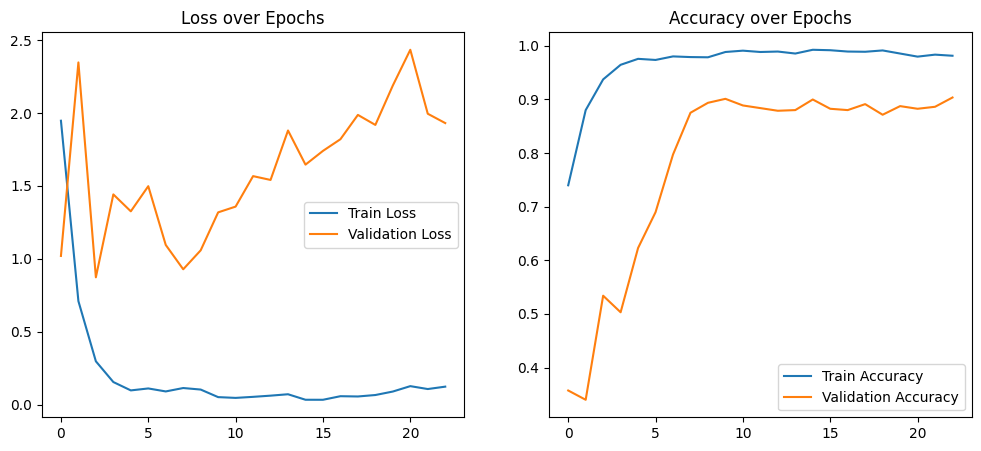

Trainable params: 86593
Non-trainable params: 192


ValueError: The filename must end in `.weights.h5`. Received: filepath=/content/drive/MyDrive/MAUS_extracted/models/stress_cnn_weights_small.h5

In [ ]:
# ================================
# 0) Install dependencies
# ================================
!pip install tensorflow scikit-learn matplotlib seaborn

# ================================
# 1) Imports
# ================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2

# ================================
# 2) Mount Google Drive
# ================================
drive.mount('/content/drive')

# ================================
# 3) Paths to preprocessed files
# ================================
DATA_DIR = '/content/drive/MyDrive/MAUS_extracted/preprocessed'
PPG_FILE = os.path.join(DATA_DIR, 'preprocessed_ppg.csv')
GSR_FILE = os.path.join(DATA_DIR, 'preprocessed_gsr.csv')
ECG_FILE = os.path.join(DATA_DIR, 'preprocessed_ecg.csv')

# ================================
# 4) Data loading
# ================================
ppg_df = pd.read_csv(PPG_FILE)
gsr_df = pd.read_csv(GSR_FILE)
ecg_df = pd.read_csv(ECG_FILE)

print("PPG shape:", ppg_df.shape)
print("GSR shape:", gsr_df.shape)
print("ECG shape:", ecg_df.shape)

# ================================
# 5) Label mapping
# ================================
def map_label(col_name):
    name_lower = col_name.lower()
    if "0back" in name_lower:
        return 0
    elif "2back" in name_lower or "3back" in name_lower:
        return 1
    else:
        return None

trial_cols = [c for c in ppg_df.columns if "trial" in c.lower()]
labels = [map_label(c) for c in trial_cols]

valid_idx = [i for i, lbl in enumerate(labels) if lbl is not None]
trial_cols = [trial_cols[i] for i in valid_idx]
labels = np.array([labels[i] for i in valid_idx])

# ================================
# 6) Prepare data
# ================================
X_ppg = ppg_df[trial_cols].T.values
X_gsr = gsr_df[trial_cols].T.values
X_ecg = ecg_df[trial_cols].T.values

X = np.stack([X_ppg, X_gsr, X_ecg], axis=-1)  # (samples, timesteps, channels)
y = labels

print("Data shape before slicing:", X.shape)

# ================================
# 7) Slice into windows
# ================================
window_size = 5000

def slice_signal(signal, window_size):
    slices = []
    total_length = signal.shape[0]
    num_slices = total_length // window_size
    for i in range(num_slices):
        start = i * window_size
        slices.append(signal[start:start + window_size])
    return np.array(slices)

X_slices = []
y_slices = []

for i in range(X.shape[0]):
    slices = slice_signal(X[i], window_size)
    X_slices.append(slices)
    y_slices.extend([y[i]] * slices.shape[0])

X_slices = np.vstack(X_slices)
y_slices = np.array(y_slices)

print("Data shape after slicing:", X_slices.shape)
print("Labels shape after slicing:", y_slices.shape)

# ================================
# 8) Augmentation: Gaussian jitter
# ================================
def gaussian_jitter(data, sigma=0.01):
    noise = np.random.normal(0, sigma * np.std(data, axis=1, keepdims=True), data.shape)
    return data + noise

X_aug = gaussian_jitter(X_slices)
y_aug = y_slices.copy()

X_all = np.concatenate([X_slices, X_aug], axis=0)
y_all = np.concatenate([y_slices, y_aug], axis=0)

print("Data shape after augmentation:", X_all.shape)

# ================================
# 9) Train/Val/Test split
# ================================
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ================================
# 10) Model Definition (Smaller CNN with L2)
# ================================
model = Sequential([
    Input(shape=(window_size, X_train.shape[2])),

    Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ================================
# 11) Early Stopping Callback
# ================================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# ================================
# 12) Training
# ================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ================================
# 13) Evaluation
# ================================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Stress', 'High Stress']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ================================
# 14) Training Curves
# ================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

# ================================
# 15) Model Parameters
# ================================
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
print("Trainable params:", trainable_params)
print("Non-trainable params:", non_trainable_params)

# ================================
# 16) Save Model
# ================================
SAVE_DIR = '/content/drive/MyDrive/MAUS_extracted/models'
os.makedirs(SAVE_DIR, exist_ok=True)
model.save(os.path.join(SAVE_DIR, 'stress_cnn_model_small.h5'))
model.save_weights(os.path.join(SAVE_DIR, 'stress_cnn_weights_small.h5'))

print("Model and weights saved to:", SAVE_DIR)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
import numpy as np

# --- Config ---
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 5  # tune after observing validation curve
MODEL_SAVE_PATH = "cnn_best_model.pth"

# --- Dataset and imbalance handling ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Simulate imbalance: keep only 10% samples of classes > 5
indices = []
for idx, (_, label) in enumerate(train_dataset):
    if label > 5:
        if np.random.rand() < 0.1:
            indices.append(idx)
    else:
        indices.append(idx)

train_dataset = Subset(train_dataset, indices)

# Compute weights for WeightedRandomSampler
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
class_sample_count = np.array([labels.count(i) for i in range(10)])
class_weights = 1. / class_sample_count
samples_weight = np.array([class_weights[label] for label in labels])
samples_weight = torch.from_numpy(samples_weight).float()

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- CNN Model with 2 dense layers ---
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 -> 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2)  # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)

# Weighted loss based on class imbalance
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Early stopping class ---
class EarlyStopping:
    def __init__(self, patience=PATIENCE, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_wts = model.state_dict()
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model_wts = model.state_dict()
            self.counter = 0

# --- Training loop ---
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_acc = correct / total

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} - Val Acc: {val_acc:.4f}")

    early_stopping(epoch_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered!")
        break

# Save best model
model.load_state_dict(early_stopping.best_model_wts)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Best model saved to {MODEL_SAVE_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PPG shape: (1689600, 8)
GSR shape: (1689600, 8)
ECG shape: (1689600, 8)
Data shape before slicing: (6, 1689600, 3)
Data shape after slicing: (2022, 5000, 3)
Labels shape after slicing: (2022,)
Data shape after augmentation: (4044, 5000, 3)
Before SMOTE - Class counts: [ 809 1617]
After SMOTE - Class counts: [1617 1617]
Epoch 1/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 61s 284ms/step - accuracy: 0.6964 - loss: 2.1411 - val_accuracy: 0.4833 - val_loss: 1.0843
Epoch 2/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 79s 273ms/step - accuracy: 0.8500 - loss: 1.0487 - val_accuracy: 0.7367 - val_loss: 0.9416
Epoch 3/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 51s 249ms/step - accuracy: 0.8950 - loss: 0.6587 - val_accuracy: 0.8591 - val_loss: 1.1421
Epoch 4/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 53s 262ms/step - accuracy: 0.9460 - loss: 0.3383 - val_accuracy: 0.8418 - val_loss: 1.5173
Epoch 5/200
203/203 ━━

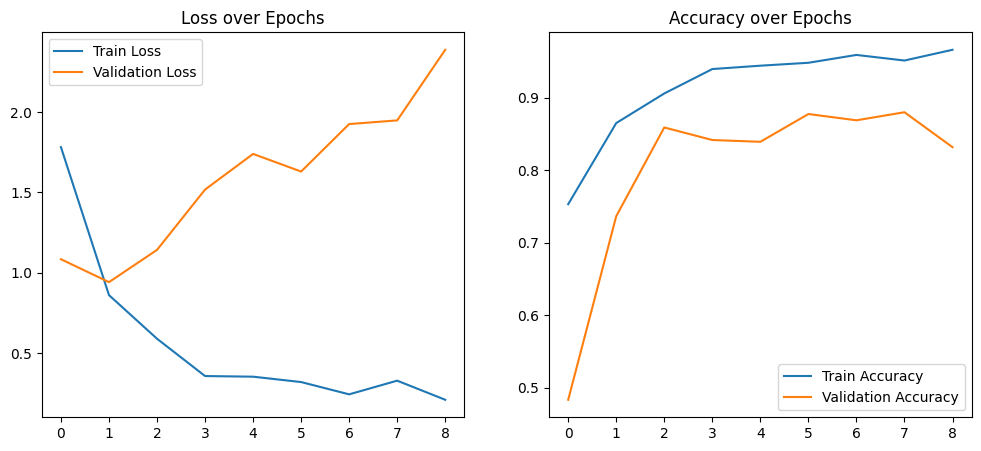

Trainable params: 86593
Non-trainable params: 192
Model and weights saved to: /content/drive/MyDrive/MAUS_extracted/models


In [ ]:
# ================================
# 0) Install dependencies
# ================================
!pip install tensorflow scikit-learn matplotlib seaborn imbalanced-learn

# ================================
# 1) Imports
# ================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2

# ================================
# 2) Mount Google Drive
# ================================
drive.mount('/content/drive')

# ================================
# 3) Paths to preprocessed files
# ================================
DATA_DIR = '/content/drive/MyDrive/MAUS_extracted/preprocessed'
PPG_FILE = os.path.join(DATA_DIR, 'preprocessed_ppg.csv')
GSR_FILE = os.path.join(DATA_DIR, 'preprocessed_gsr.csv')
ECG_FILE = os.path.join(DATA_DIR, 'preprocessed_ecg.csv')

# ================================
# 4) Data loading
# ================================
ppg_df = pd.read_csv(PPG_FILE)
gsr_df = pd.read_csv(GSR_FILE)
ecg_df = pd.read_csv(ECG_FILE)

print("PPG shape:", ppg_df.shape)
print("GSR shape:", gsr_df.shape)
print("ECG shape:", ecg_df.shape)

# ================================
# 5) Label mapping
# ================================
def map_label(col_name):
    name_lower = col_name.lower()
    if "0back" in name_lower:
        return 0
    elif "2back" in name_lower or "3back" in name_lower:
        return 1
    else:
        return None

trial_cols = [c for c in ppg_df.columns if "trial" in c.lower()]
labels = [map_label(c) for c in trial_cols]
valid_idx = [i for i, lbl in enumerate(labels) if lbl is not None]
trial_cols = [trial_cols[i] for i in valid_idx]
labels = np.array([labels[i] for i in valid_idx])

# ================================
# 6) Prepare data
# ================================
X_ppg = ppg_df[trial_cols].T.values
X_gsr = gsr_df[trial_cols].T.values
X_ecg = ecg_df[trial_cols].T.values

X = np.stack([X_ppg, X_gsr, X_ecg], axis=-1)  # (samples, timesteps, channels)
y = labels

print("Data shape before slicing:", X.shape)

# ================================
# 7) Slice into windows
# ================================
window_size = 5000

def slice_signal(signal, window_size):
    slices = []
    total_length = signal.shape[0]
    num_slices = total_length // window_size
    for i in range(num_slices):
        start = i * window_size
        slices.append(signal[start:start + window_size])
    return np.array(slices)

X_slices, y_slices = [], []
for i in range(X.shape[0]):
    slices = slice_signal(X[i], window_size)
    X_slices.append(slices)
    y_slices.extend([y[i]] * slices.shape[0])

X_slices = np.vstack(X_slices)
y_slices = np.array(y_slices)

print("Data shape after slicing:", X_slices.shape)
print("Labels shape after slicing:", y_slices.shape)

# ================================
# 8) Augmentation: Gaussian jitter
# ================================
def gaussian_jitter(data, sigma=0.01):
    noise = np.random.normal(0, sigma * np.std(data, axis=1, keepdims=True), data.shape)
    return data + noise

X_aug = gaussian_jitter(X_slices)
y_aug = y_slices.copy()

X_all = np.concatenate([X_slices, X_aug], axis=0)
y_all = np.concatenate([y_slices, y_aug], axis=0)

print("Data shape after augmentation:", X_all.shape)

# ================================
# 9) Train/Val/Test split
# ================================
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Before SMOTE - Class counts:", np.bincount(y_train))

# ================================
# 10) SMOTE for time-series CNN
# ================================
# Flatten time-series for SMOTE
nsamples, ntimesteps, nchannels = X_train.shape
X_train_flat = X_train.reshape((nsamples, ntimesteps * nchannels))

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_flat, y_train)

# Reshape back to (timesteps, channels)
X_train_res = X_train_res.reshape((-1, ntimesteps, nchannels))
print("After SMOTE - Class counts:", np.bincount(y_train_res))

# ================================
# 11) Model Definition (Smaller CNN with Dropout & L2)
# ================================
model = Sequential([
    Input(shape=(window_size, X_train.shape[2])),

    Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ================================
# 12) Early Stopping Callback
# ================================
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# ================================
# 13) Training
# ================================
history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,  # smaller batch to reduce overfitting
    callbacks=[early_stop],
    verbose=1
)

# ================================
# 14) Evaluation
# ================================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Stress', 'High Stress']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ================================
# 15) Training Curves
# ================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

# ================================
# 16) Model Parameters
# ================================
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
print("Trainable params:", trainable_params)
print("Non-trainable params:", non_trainable_params)

# ================================
# 17) Save Model (error-free)
# ================================
SAVE_DIR = '/content/drive/MyDrive/MAUS_extracted/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save in both formats
model.save(os.path.join(SAVE_DIR, 'stress_cnn_model_small.keras'))
model.save(os.path.join(SAVE_DIR, 'stress_cnn_model_small.h5'), save_format='h5')

# Save weights correctly
model.save_weights(os.path.join(SAVE_DIR, 'stress_cnn_weights_small.weights.h5'))

print("Model and weights saved to:", SAVE_DIR)


trying better moodel with dense layer n reduced filter size

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PPG shape: (1689600, 8)
GSR shape: (1689600, 8)
ECG shape: (1689600, 8)
Epoch 1/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 78s 364ms/step - accuracy: 0.7186 - loss: 3.8448 - val_accuracy: 0.7515 - val_loss: 4.8719
Epoch 2/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 396ms/step - accuracy: 0.8844 - loss: 0.3964 - val_accuracy: 0.8368 - val_loss: 2.5686
Epoch 3/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 72s 349ms/step - accuracy: 0.9206 - loss: 0.2810 - val_accuracy: 0.8739 - val_loss: 0.4384
Epoch 4/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 84s 360ms/step - accuracy: 0.9581 - loss: 0.1461 - val_accuracy: 0.8850 - val_loss: 0.4856
Epoch 5/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 75s 328ms/step - accuracy: 0.9788 - loss: 0.0980 - val_accuracy: 0.8838 - val_loss: 0.4137
Epoch 6/200
203/203 ━━━━━━━━━━━━━━━━━━━━ 66s 323ms/step - accuracy: 0.9881 - loss: 0.0258 - val_accuracy: 0.9110 - val_loss: 0.4722
Epoch 7

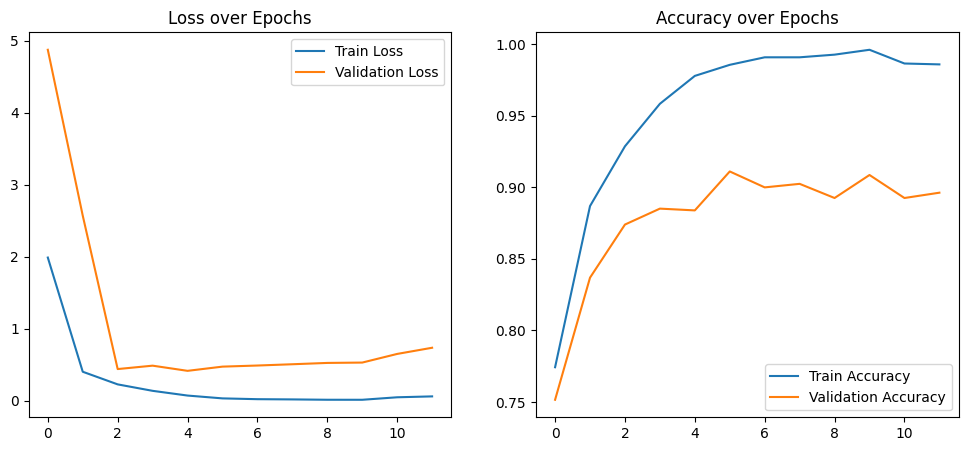

Trainable params: 5118657
Non-trainable params: 192


ValueError: The filename must end in `.weights.h5`. Received: filepath=/content/drive/MyDrive/MAUS_extracted/models/stress_cnn_weights_small.weights_1.h5

In [ ]:

import sys
import subprocess

def install_packages(packages):
    subprocess.run(
        [sys.executable, "-m", "pip", "install"] + packages,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

install_packages([
    "tensorflow",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "imbalanced-learn"
])



# aall  Imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2


drive.mount('/content/drive')


#  Paths to preprocessed files
DATA_DIR = '/content/drive/MyDrive/MAUS_extracted/preprocessed'
PPG_FILE = os.path.join(DATA_DIR, 'preprocessed_ppg.csv')
GSR_FILE = os.path.join(DATA_DIR, 'preprocessed_gsr.csv')
ECG_FILE = os.path.join(DATA_DIR, 'preprocessed_ecg.csv')


# 4) loadint the data

ppg_df = pd.read_csv(PPG_FILE)
gsr_df = pd.read_csv(GSR_FILE)
ecg_df = pd.read_csv(ECG_FILE)

print("PPG shape:", ppg_df.shape)
print("GSR shape:", gsr_df.shape)
print("ECG shape:", ecg_df.shape)


# 5) assigning labels

def map_label(col_name):
    name_lower = col_name.lower()
    if "0back" in name_lower:
        return 0
    elif "2back" in name_lower or "3back" in name_lower:
        return 1
    else:
        return None

trial_cols = [c for c in ppg_df.columns if "trial" in c.lower()]
labels = [map_label(c) for c in trial_cols]
valid_idx = [i for i, lbl in enumerate(labels) if lbl is not None]
trial_cols = [trial_cols[i] for i in valid_idx]
labels = np.array([labels[i] for i in valid_idx])


#  Prepare data

X_ppg = ppg_df[trial_cols].T.values
X_gsr = gsr_df[trial_cols].T.values
X_ecg = ecg_df[trial_cols].T.values

X = np.stack([X_ppg, X_gsr, X_ecg], axis=-1)
y = labels


#  Slice into windows

window_size = 5000

def slice_signal(signal, window_size):
    slices = []
    total_length = signal.shape[0]
    num_slices = total_length // window_size
    for i in range(num_slices):
        start = i * window_size
        slices.append(signal[start:start + window_size])
    return np.array(slices)

X_slices, y_slices = [], []
for i in range(X.shape[0]):
    slices = slice_signal(X[i], window_size)
    X_slices.append(slices)
    y_slices.extend([y[i]] * slices.shape[0])

X_slices = np.vstack(X_slices)
y_slices = np.array(y_slices)


#  Augmentation

def gaussian_jitter(data, sigma=0.01):
    noise = np.random.normal(0, sigma * np.std(data, axis=1, keepdims=True), data.shape)
    return data + noise

X_aug = gaussian_jitter(X_slices)
y_aug = y_slices.copy()

X_all = np.concatenate([X_slices, X_aug], axis=0)
y_all = np.concatenate([y_slices, y_aug], axis=0)


# 9) splitting to test train n validate

X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


#  SMOTE

nsamples, ntimesteps, nchannels = X_train.shape
X_train_flat = X_train.reshape((nsamples, ntimesteps * nchannels))
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_flat, y_train)
X_train_res = X_train_res.reshape((-1, ntimesteps, nchannels))


#  CNN Model with BatchNorm and L2 and  Extra Dense layber

model = Sequential([
    Input(shape=(window_size, X_train.shape[2])),

    Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


#  Early Stopping

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)


# fitting train model

history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


#  Evaluation

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Stress', 'High Stress']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

#  Plot training curves

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

#  number of parameters

trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
print("Trainable params:", trainable_params)
print("Non-trainable params:", non_trainable_params)


#  Save Model(has an error here need to rerun)

SAVE_DIR = '/content/drive/MyDrive/MAUS_extracted/models'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, 'stress_cnn_model_small_1.keras'))
model.save(os.path.join(SAVE_DIR, 'stress_cnn_model_small_1.h5'), save_format='h5')
model.save_weights(os.path.join(SAVE_DIR, 'stress_cnn_weights_small_1.weights.h5'))

print("Model and weights saved to:", SAVE_DIR)
